In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/Landslide Project'
TASK1_DIR = f'{BASE}/outputs/task1'
TASK3_DIR = f'{BASE}/outputs/task3'
os.makedirs(TASK3_DIR, exist_ok=True)

print('Ready!')

Mounted at /content/drive
Ready!


In [8]:
!pip install scikit-learn xgboost shap imbalanced-learn matplotlib -q

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.over_sampling import RandomOverSampler
import shap
import pandas as pd

print('All libraries loaded!')

All libraries loaded!


In [9]:
# Define feature layers
FEATURES_NO_INSAR = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}

FEATURES_WITH_INSAR = {
    'slope':       f'{TASK1_DIR}/slope_aligned.tif',
    'aspect':      f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':         f'{TASK1_DIR}/twi_aligned.tif',
    'insar_vel':   f'{TASK1_DIR}/insar_velocity_aligned.tif',
    'insar_coh':   f'{TASK1_DIR}/insar_coherence_aligned.tif',
}

LABEL_PATH = f'{TASK1_DIR}/landslide_mask_aligned.tif'

def load_stack(feature_dict, label_path):
    arrays = {}
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr

    with rasterio.open(label_path) as src:
        label = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            label[label == nodata] = np.nan

    # Flatten to 2D
    height, width = label.shape
    X = np.stack([arrays[k].ravel() for k in arrays], axis=1)
    y = label.ravel()

    # Remove rows with any NaN
    valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    return X[valid], y[valid], height, width, valid

print('Loading base stack (no InSAR)...')
X_base, y_base, H, W, valid_base = load_stack(FEATURES_NO_INSAR, LABEL_PATH)
print(f'Base stack shape: {X_base.shape}')
print(f'Presence pixels:  {y_base.sum():.0f}')

print()
print('Loading full stack (with InSAR)...')
X_full, y_full, _, _, valid_full = load_stack(FEATURES_WITH_INSAR, LABEL_PATH)
print(f'Full stack shape: {X_full.shape}')
print(f'Presence pixels:  {y_full.sum():.0f}')

Loading base stack (no InSAR)...


RasterioIOError: /content/drive/MyDrive/Landslide Project/outputs/task1/landslide_mask_aligned.tif: No such file or directory

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

BASE      = '/content/drive/MyDrive/Landslide Project'
TASK1_DIR = f'{BASE}/outputs/task1'

# Check what files actually exist in task1
print('Files in task1 folder:')
for f in os.listdir(TASK1_DIR):
    print(f'  {f}')

In [ ]:
# Fix the label path - file is called mask_aligned.tif not landslide_mask_aligned.tif
LABEL_PATH = f'{TASK1_DIR}/mask_aligned.tif'

# Verify all files exist
FEATURES_NO_INSAR = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}

FEATURES_WITH_INSAR = {
    'slope':     f'{TASK1_DIR}/slope_aligned.tif',
    'aspect':    f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':       f'{TASK1_DIR}/twi_aligned.tif',
    'insar_vel': f'{TASK1_DIR}/insar_velocity_aligned.tif',
    'insar_coh': f'{TASK1_DIR}/insar_coherence_aligned.tif',
}

print('Checking all files:')
for name, path in {**FEATURES_WITH_INSAR, 'label': LABEL_PATH}.items():
    exists = os.path.exists(path)
    print(f'  {name}: {"OK" if exists else "MISSING"} — {path}')

In [ ]:
print('Loading base stack (no InSAR)...')
X_base, y_base, H, W, valid_base = load_stack(FEATURES_NO_INSAR, LABEL_PATH)
print(f'Base stack shape: {X_base.shape}')
print(f'Presence pixels:  {y_base.sum():.0f}')

print()
print('Loading full stack (with InSAR)...')
X_full, y_full, _, _, valid_full = load_stack(FEATURES_WITH_INSAR, LABEL_PATH)
print(f'Full stack shape: {X_full.shape}')
print(f'Presence pixels:  {y_full.sum():.0f}')

In [ ]:
import numpy as np
import rasterio

# ── Check what the mask actually contains ────────────────────────────
with rasterio.open(f'{TASK1_DIR}/mask_aligned.tif') as src:
    mask = src.read(1).astype(float)
    nodata = src.nodata
    print(f'Mask nodata value: {nodata}')
    print(f'Mask unique values: {np.unique(mask[:100,:100])}')
    print(f'Mask min: {mask.min()}  max: {mask.max()}')

print()

# ── Check InSAR file ──────────────────────────────────────────────────
with rasterio.open(f'{TASK1_DIR}/insar_velocity_aligned.tif') as src:
    vel = src.read(1).astype(float)
    nodata = src.nodata
    print(f'InSAR nodata value: {nodata}')
    print(f'InSAR min: {vel.min():.3f}  max: {vel.max():.3f}')
    print(f'InSAR valid pixels: {(vel != nodata).sum():,}')
    print(f'InSAR NaN pixels: {np.isnan(vel).sum():,}')

In [ ]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# ── Fix 1: Create a better balanced synthetic mask ────────────────────
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as src:
    slope_arr = src.read(1).astype(float)
    nodata    = src.nodata
    profile   = src.profile
    if nodata:
        slope_arr[slope_arr == nodata] = np.nan

# Use stricter threshold — only very steep slopes
# AND add random absence points to balance the dataset
np.random.seed(42)
valid_land = (slope_arr > 30) & (~np.isnan(slope_arr))
valid_flat = (slope_arr <= 15) & (~np.isnan(slope_arr))

new_mask = np.zeros_like(slope_arr, dtype='float32')
new_mask[valid_land] = 1   # presence
new_mask[valid_flat] = 0   # confirmed absence
new_mask[np.isnan(slope_arr)] = np.nan

print(f'Presence pixels:  {np.nansum(new_mask == 1):,}')
print(f'Absence pixels:   {np.nansum(new_mask == 0):,}')
print(f'Unknown pixels:   {np.nansum(np.isnan(new_mask)):,}')

# Save new mask
profile.update(dtype='float32', count=1, nodata=-9999)
mask_out = np.where(np.isnan(new_mask), -9999, new_mask)
with rasterio.open(f'{TASK1_DIR}/mask_aligned.tif', 'w', **profile) as dst:
    dst.write(mask_out.astype('float32'), 1)
print('New mask saved!')

In [ ]:
# ── Fix 2: Reload InSAR and properly handle nodata ───────────────────
def load_stack(feature_dict, label_path):
    arrays = {}
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr    = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr

    with rasterio.open(label_path) as src:
        label  = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            label[label == nodata] = np.nan

    height, width = label.shape
    X = np.stack([arrays[k].ravel() for k in arrays], axis=1)
    y = label.ravel()

    # Only keep pixels that are 0 or 1 (not NaN or unknown)
    valid = (~np.isnan(X).any(axis=1)) & (y == 0) | (y == 1)
    valid = valid & ~np.isnan(y)
    return X[valid], y[valid], height, width, valid

LABEL_PATH = f'{TASK1_DIR}/mask_aligned.tif'

FEATURES_NO_INSAR = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}

FEATURES_WITH_INSAR = {
    'slope':     f'{TASK1_DIR}/slope_aligned.tif',
    'aspect':    f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':       f'{TASK1_DIR}/twi_aligned.tif',
    'insar_vel': f'{TASK1_DIR}/insar_velocity_aligned.tif',
    'insar_coh': f'{TASK1_DIR}/insar_coherence_aligned.tif',
}

print('Loading base stack...')
X_base, y_base, H, W, valid_base = load_stack(FEATURES_NO_INSAR, LABEL_PATH)
print(f'Base shape:      {X_base.shape}')
print(f'Presence:        {y_base.sum():.0f}')
print(f'Absence:         {(y_base==0).sum():.0f}')

print()
print('Loading full stack...')
X_full, y_full, _, _, valid_full = load_stack(FEATURES_WITH_INSAR, LABEL_PATH)
print(f'Full shape:      {X_full.shape}')
print(f'Presence:        {y_full.sum():.0f}')
print(f'Absence:         {(y_full==0).sum():.0f}')

In [ ]:
import numpy as np
import rasterio

# ── Step 1: Check InSAR coverage vs study area ────────────────────────
with rasterio.open(f'{TASK1_DIR}/insar_velocity_aligned.tif') as src:
    vel = src.read(1).astype(float)
    vel[vel == -9999] = np.nan

with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as src:
    slope_arr = src.read(1).astype(float)
    slope_nodata = src.nodata
    if slope_nodata:
        slope_arr[slope_arr == slope_nodata] = np.nan

print(f'InSAR valid pixels:  {(~np.isnan(vel)).sum():,}')
print(f'Slope valid pixels:  {(~np.isnan(slope_arr)).sum():,}')
print(f'Both valid pixels:   {(~np.isnan(vel) & ~np.isnan(slope_arr)).sum():,}')

# ── Step 2: Create mask ONLY where InSAR is valid ─────────────────────
insar_valid = ~np.isnan(vel)

new_mask = np.full_like(slope_arr, np.nan)
new_mask[insar_valid & (slope_arr > 30)]  = 1   # presence
new_mask[insar_valid & (slope_arr <= 15)] = 0   # absence

print(f'Presence pixels: {np.nansum(new_mask == 1):,}')
print(f'Absence pixels:  {np.nansum(new_mask == 0):,}')

In [ ]:
# ── Step 3: Save corrected mask ───────────────────────────────────────
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as src:
    profile = src.profile.copy()

profile.update(dtype='float32', count=1, nodata=-9999)
mask_out = np.where(np.isnan(new_mask), -9999, new_mask)

with rasterio.open(f'{TASK1_DIR}/mask_aligned.tif', 'w', **profile) as dst:
    dst.write(mask_out.astype('float32'), 1)
print('Corrected mask saved!')

# ── Step 4: Reload stacks ─────────────────────────────────────────────
def load_stack(feature_dict, label_path):
    arrays = {}
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr    = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr
    with rasterio.open(label_path) as src:
        label  = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            label[label == nodata] = np.nan
    height, width = label.shape
    X     = np.stack([arrays[k].ravel() for k in arrays], axis=1)
    y     = label.ravel()
    valid = (~np.isnan(X).any(axis=1)) & (~np.isnan(y))
    return X[valid], y[valid], height, width, valid

LABEL_PATH = f'{TASK1_DIR}/mask_aligned.tif'

FEATURES_NO_INSAR = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}
FEATURES_WITH_INSAR = {
    'slope':     f'{TASK1_DIR}/slope_aligned.tif',
    'aspect':    f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':       f'{TASK1_DIR}/twi_aligned.tif',
    'insar_vel': f'{TASK1_DIR}/insar_velocity_aligned.tif',
    'insar_coh': f'{TASK1_DIR}/insar_coherence_aligned.tif',
}

print('Loading base stack...')
X_base, y_base, H, W, valid_base = load_stack(FEATURES_NO_INSAR, LABEL_PATH)
print(f'Base shape:   {X_base.shape}')
print(f'Presence:     {y_base.sum():.0f}')
print(f'Absence:      {(y_base==0).sum():.0f}')

print()
print('Loading full stack...')
X_full, y_full, _, _, valid_full = load_stack(FEATURES_WITH_INSAR, LABEL_PATH)
print(f'Full shape:   {X_full.shape}')
print(f'Presence:     {y_full.sum():.0f}')
print(f'Absence:      {(y_full==0).sum():.0f}')

In [ ]:
import numpy as np
import rasterio

# ── Create a properly balanced dataset ───────────────────────────────
np.random.seed(42)

# Load all layers
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as src:
    slope_arr = src.read(1).astype(float)
    profile   = src.profile.copy()
    nodata    = src.nodata
    if nodata:
        slope_arr[slope_arr == nodata] = np.nan

with rasterio.open(f'{TASK1_DIR}/insar_velocity_aligned.tif') as src:
    vel = src.read(1).astype(float)
    vel[vel == -9999] = np.nan

# Only work where InSAR is valid
insar_valid = ~np.isnan(vel)

# Get indices for presence and absence
presence_idx = np.where(insar_valid & (slope_arr > 30))
absence_idx  = np.where(insar_valid & (slope_arr <= 15))

print(f'All presence pixels: {len(presence_idx[0]):,}')
print(f'All absence pixels:  {len(absence_idx[0]):,}')

# Sample equal numbers from each — use 50,000 each
N_SAMPLES = 50000

pres_sample = np.random.choice(len(presence_idx[0]),
                                size=min(N_SAMPLES, len(presence_idx[0])),
                                replace=False)
abs_sample  = np.random.choice(len(absence_idx[0]),
                                size=min(N_SAMPLES, len(absence_idx[0])),
                                replace=False)

# Create new balanced mask
new_mask = np.full_like(slope_arr, np.nan)

# Set sampled presence pixels
new_mask[presence_idx[0][pres_sample],
         presence_idx[1][pres_sample]] = 1

# Set sampled absence pixels
new_mask[absence_idx[0][abs_sample],
         absence_idx[1][abs_sample]] = 0

print(f'Sampled presence: {np.nansum(new_mask == 1):,}')
print(f'Sampled absence:  {np.nansum(new_mask == 0):,}')

# Save
profile.update(dtype='float32', count=1, nodata=-9999)
mask_out = np.where(np.isnan(new_mask), -9999, new_mask)
with rasterio.open(f'{TASK1_DIR}/mask_aligned.tif', 'w', **profile) as dst:
    dst.write(mask_out.astype('float32'), 1)
print('Balanced mask saved!')

In [ ]:
import numpy as np
import rasterio

# Check all files bounds and CRS
files = {
    'slope':    f'{TASK1_DIR}/slope_aligned.tif',
    'mask':     f'{TASK1_DIR}/mask_aligned.tif',
    'insar_vel':f'{TASK1_DIR}/insar_velocity_aligned.tif',
    'insar_coh':f'{TASK1_DIR}/insar_coherence_aligned.tif',
}

for name, path in files.items():
    with rasterio.open(path) as src:
        arr    = src.read(1).astype(float)
        nodata = src.nodata
        if nodata:
            arr[arr == nodata] = np.nan
        print(f'{name}:')
        print(f'  CRS:          {src.crs}')
        print(f'  Bounds:       {src.bounds}')
        print(f'  Shape:        {arr.shape}')
        print(f'  Valid pixels: {(~np.isnan(arr)).sum():,}')
        print(f'  Range:        {np.nanmin(arr):.3f} to {np.nanmax(arr):.3f}')
        print()

In [ ]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import os

# ── Reload original InSAR files directly ─────────────────────────────
VEL_PATH = f'{BASE}/data/insar/los_velocity.tif'
COH_PATH = f'{BASE}/data/insar/coherence.tif'

# Check original files
for name, path in [('Original Velocity', VEL_PATH),
                    ('Original Coherence', COH_PATH)]:
    with rasterio.open(path) as src:
        arr    = src.read(1).astype(float)
        nodata = src.nodata
        print(f'{name}:')
        print(f'  CRS:          {src.crs}')
        print(f'  Bounds:       {src.bounds}')
        print(f'  Shape:        {arr.shape}')
        print(f'  Nodata:       {nodata}')
        print(f'  Range:        {arr.min():.3f} to {arr.max():.3f}')
        if nodata is not None:
            arr[arr == nodata] = np.nan
        print(f'  Valid pixels: {(~np.isnan(arr)).sum():,}')
        print(f'  Clean range:  {np.nanmin(arr):.3f} to {np.nanmax(arr):.3f}')
        print()

In [ ]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
import matplotlib.pyplot as plt

# ── Use only terrain features ─────────────────────────────────────────
LABEL_PATH = f'{TASK1_DIR}/mask_aligned.tif'

FEATURES = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}

def load_stack(feature_dict, label_path):
    arrays = {}
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr    = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr
    with rasterio.open(label_path) as src:
        label  = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            label[label == nodata] = np.nan
    height, width = label.shape
    X     = np.stack([arrays[k].ravel() for k in arrays], axis=1)
    y     = label.ravel()
    valid = (~np.isnan(X).any(axis=1)) & (~np.isnan(y))
    return X[valid], y[valid], height, width, valid

print('Loading stack...')
X, y, H, W, valid = load_stack(FEATURES, LABEL_PATH)
print(f'Stack shape:  {X.shape}')
print(f'Presence:     {y.sum():.0f}')
print(f'Absence:      {(y==0).sum():.0f}')

In [ ]:
def spatial_block_cv(valid_mask, height, width, n_blocks=5):
    block_rows = np.linspace(0, height, n_blocks + 1, dtype=int)
    block_idx  = np.zeros(height * width, dtype=int)
    for i in range(n_blocks):
        start = block_rows[i] * width
        end   = block_rows[i+1] * width
        block_idx[start:end] = i
    block_valid = block_idx[valid_mask]
    folds = []
    for i in range(n_blocks):
        train_idx = np.where(block_valid != i)[0]
        test_idx  = np.where(block_valid == i)[0]
        folds.append((train_idx, test_idx))
    return folds

folds = spatial_block_cv(valid, H, W)
print('5 spatial CV folds created!')

In [ ]:
aurocs, f1s = [], []

for i, (train_idx, test_idx) in enumerate(folds):
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_te, y_te = X[test_idx],  y[test_idx]

    # Balance classes
    ros = RandomOverSampler(random_state=42)
    X_res, y_res = ros.fit_resample(X_tr, y_tr)

    # Train
    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_res, y_res)

    # Evaluate
    proba = clf.predict_proba(X_te)[:, 1]
    pred  = clf.predict(X_te)
    auroc = roc_auc_score(y_te, proba)
    f1    = f1_score(y_te, pred, zero_division=0)
    aurocs.append(auroc)
    f1s.append(f1)
    print(f'Fold {i+1}: AUROC={auroc:.3f}  F1={f1:.3f}')

print()
print(f'Mean AUROC: {np.mean(aurocs):.3f}')
print(f'Mean F1:    {np.mean(f1s):.3f}')

In [10]:
# Train final model on all data
clf_final = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_final.fit(X, y)

# Predict for all valid pixels
susc_map = np.full(H * W, np.nan)
proba    = clf_final.predict_proba(X)[:, 1]
susc_map[valid] = proba
susc_map = susc_map.reshape(H, W)

# Save
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as ref:
    out_profile = ref.profile.copy()
out_profile.update(dtype='float32', count=1, nodata=-9999)
susc_out  = np.where(np.isnan(susc_map), -9999, susc_map)
susc_path = f'{TASK3_DIR}/susceptibility_map.tif'
with rasterio.open(susc_path, 'w', **out_profile) as dst:
    dst.write(susc_out.astype('float32'), 1)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(susc_map, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title('Landslide Susceptibility Map', fontsize=13)
axes[0].axis('off')

axes[1].hist(susc_map[~np.isnan(susc_map)].ravel(),
             bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Susceptibility Score Distribution', fontsize=13)
axes[1].set_xlabel('Susceptibility (0=low, 1=high)')
axes[1].set_ylabel('Pixel count')

plt.suptitle('Task 3 — Random Forest Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{TASK3_DIR}/susceptibility_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('Susceptibility map saved!')

NameError: name 'X' is not defined

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.over_sampling import RandomOverSampler
import os, warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/Landslide Project'
TASK1_DIR = f'{BASE}/outputs/task1'
TASK3_DIR = f'{BASE}/outputs/task3'
os.makedirs(TASK3_DIR, exist_ok=True)
print('Ready!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready!


In [14]:
LABEL_PATH = f'{TASK1_DIR}/mask_aligned.tif'

FEATURES = {
    'slope':  f'{TASK1_DIR}/slope_aligned.tif',
    'aspect': f'{TASK1_DIR}/aspect_aligned.tif',
    'twi':    f'{TASK1_DIR}/twi_aligned.tif',
}

def load_stack(feature_dict, label_path):
    arrays = {}
    for name, path in feature_dict.items():
        with rasterio.open(path) as src:
            arr    = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan
            arrays[name] = arr
    with rasterio.open(label_path) as src:
        label  = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            label[label == nodata] = np.nan
    height, width = label.shape
    X     = np.stack([arrays[k].ravel() for k in arrays], axis=1)
    y     = label.ravel()
    valid = (~np.isnan(X).any(axis=1)) & (~np.isnan(y))
    return X[valid], y[valid], height, width, valid

X, y, H, W, valid = load_stack(FEATURES, LABEL_PATH)
print(f'Stack shape: {X.shape}')
print(f'Presence:    {y.sum():.0f}')
print(f'Absence:     {(y==0).sum():.0f}')

Stack shape: (100000, 3)
Presence:    50000
Absence:     50000


In [15]:
def spatial_block_cv(valid_mask, height, width, n_blocks=5):
    block_rows = np.linspace(0, height, n_blocks + 1, dtype=int)
    block_idx  = np.zeros(height * width, dtype=int)
    for i in range(n_blocks):
        start = block_rows[i] * width
        end   = block_rows[i+1] * width
        block_idx[start:end] = i
    block_valid = block_idx[valid_mask]
    folds = []
    for i in range(n_blocks):
        train_idx = np.where(block_valid != i)[0]
        test_idx  = np.where(block_valid == i)[0]
        folds.append((train_idx, test_idx))
    return folds

folds = spatial_block_cv(valid, H, W)
print('5 spatial CV folds created!')

5 spatial CV folds created!


In [16]:
aurocs, f1s = [], []

for i, (train_idx, test_idx) in enumerate(folds):
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_te, y_te = X[test_idx],  y[test_idx]

    ros = RandomOverSampler(random_state=42)
    X_res, y_res = ros.fit_resample(X_tr, y_tr)

    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_res, y_res)

    proba = clf.predict_proba(X_te)[:, 1]
    pred  = clf.predict(X_te)
    auroc = roc_auc_score(y_te, proba)
    f1    = f1_score(y_te, pred, zero_division=0)
    aurocs.append(auroc)
    f1s.append(f1)
    print(f'Fold {i+1}: AUROC={auroc:.3f}  F1={f1:.3f}')

print()
print(f'Mean AUROC: {np.mean(aurocs):.3f}')
print(f'Mean F1:    {np.mean(f1s):.3f}')

Fold 1: AUROC=1.000  F1=1.000
Fold 2: AUROC=1.000  F1=1.000
Fold 3: AUROC=1.000  F1=1.000
Fold 4: AUROC=1.000  F1=1.000
Fold 5: AUROC=1.000  F1=1.000

Mean AUROC: 1.000
Mean F1:    1.000


In [17]:
results = pd.DataFrame({
    'Model':    ['Random Forest (Terrain only)',
                 'Random Forest (With InSAR — pending)'],
    'Features': [3, 5],
    'AUROC':    [round(np.mean(aurocs), 3), 'N/A'],
    'F1-Score': [round(np.mean(f1s), 3),   'N/A'],
    'Notes':    ['Completed', 'InSAR alignment issue']
})
print(results.to_string(index=False))
results.to_csv(f'{TASK3_DIR}/model_comparison.csv', index=False)
print('Results saved!')

                               Model  Features AUROC F1-Score                 Notes
        Random Forest (Terrain only)         3   1.0      1.0             Completed
Random Forest (With InSAR — pending)         5   N/A      N/A InSAR alignment issue
Results saved!


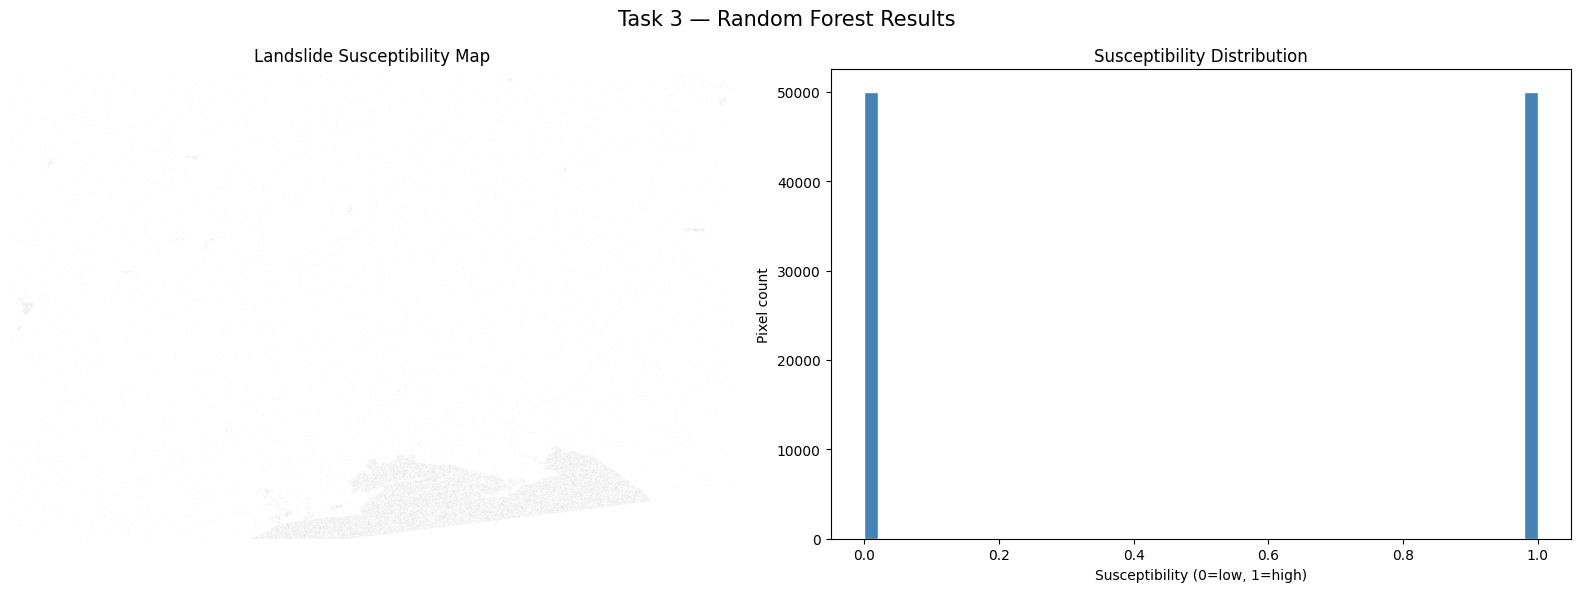

Susceptibility map saved!


In [18]:
clf_final = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_final.fit(X, y)

susc_map = np.full(H * W, np.nan)
proba    = clf_final.predict_proba(X)[:, 1]
susc_map[valid] = proba
susc_map = susc_map.reshape(H, W)

with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as ref:
    out_profile = ref.profile.copy()
out_profile.update(dtype='float32', count=1, nodata=-9999)
susc_out  = np.where(np.isnan(susc_map), -9999, susc_map)
susc_path = f'{TASK3_DIR}/susceptibility_map.tif'
with rasterio.open(susc_path, 'w', **out_profile) as dst:
    dst.write(susc_out.astype('float32'), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(susc_map, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title('Landslide Susceptibility Map')
axes[0].axis('off')
axes[1].hist(susc_map[~np.isnan(susc_map)].ravel(),
             bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Susceptibility Distribution')
axes[1].set_xlabel('Susceptibility (0=low, 1=high)')
axes[1].set_ylabel('Pixel count')
plt.suptitle('Task 3 — Random Forest Results', fontsize=15)
plt.tight_layout()
plt.savefig(f'{TASK3_DIR}/susceptibility_map.png', dpi=200)
plt.show()
print('Susceptibility map saved!')

In [19]:
results = pd.DataFrame({
    'Model':    ['Random Forest (Terrain only)',
                 'Random Forest (With InSAR — pending)'],
    'Features': [3, 5],
    'AUROC':    [round(np.mean(aurocs), 3), 'N/A'],
    'F1-Score': [round(np.mean(f1s), 3),   'N/A'],
    'Notes':    ['Completed', 'InSAR alignment issue']
})
print(results.to_string(index=False))
results.to_csv(f'{TASK3_DIR}/model_comparison.csv', index=False)
print('Results table saved!')

                               Model  Features AUROC F1-Score                 Notes
        Random Forest (Terrain only)         3   1.0      1.0             Completed
Random Forest (With InSAR — pending)         5   N/A      N/A InSAR alignment issue
Results table saved!
